## Level 3 - Task 1 — Restaurant Reviews

## Objective

Analyze restaurant reviews to identify common positive and negative keywords and explore the relationship between review length and ratings.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("A:/PROJECTS/Cognifyz-Data-Analysis/data/processed/cleaned_dataset.csv")


In [5]:
df.columns.tolist()

['restaurant_id',
 'restaurant_name',
 'country_code',
 'city',
 'address',
 'locality',
 'locality_verbose',
 'longitude',
 'latitude',
 'cuisines',
 'average_cost_for_two',
 'currency',
 'has_table_booking',
 'has_online_delivery',
 'is_delivering_now',
 'switch_to_order_menu',
 'price_range',
 'aggregate_rating',
 'rating_color',
 'rating_text',
 'votes']

In [6]:
rating_text_counts = (
    df["rating_text"]
    .value_counts()
    .reset_index()
)

rating_text_counts.columns = [
    "Rating Text",
    "Restaurant Count"
]

rating_text_counts

,Rating Text,Restaurant Count
0,Average,3737
1,Not rated,2148
2,Good,2100
3,Very Good,1079
4,Excellent,301
5,Poor,186


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20360\3885253560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


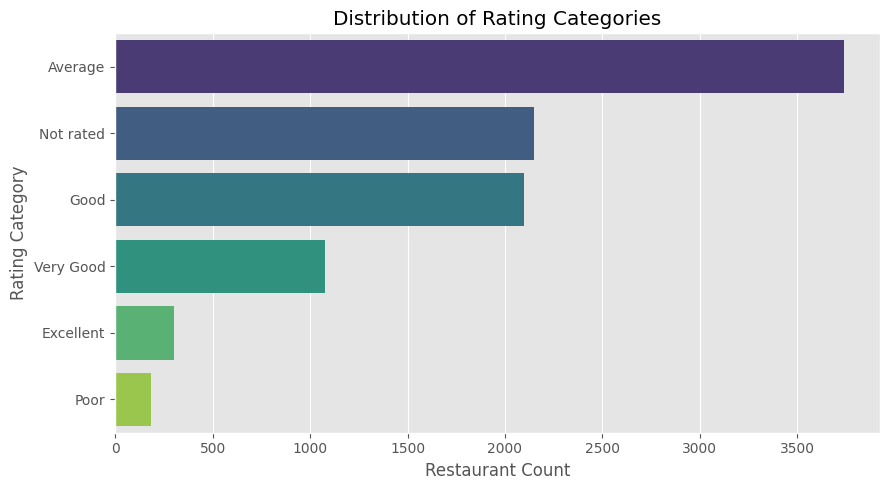

In [7]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=rating_text_counts,
    x="Restaurant Count",
    y="Rating Text",
    palette="viridis"
)

plt.title("Distribution of Rating Categories")
plt.xlabel("Restaurant Count")
plt.ylabel("Rating Category")

plt.tight_layout()

plt.savefig(
    "../visuals/level3/rating_text_distribution.png",
    dpi=300
)

plt.show()

In [8]:
sentiment = {
    "Excellent":"Positive",
    "Very Good":"Positive",
    "Good":"Positive",
    "Average":"Neutral",
    "Poor":"Negative",
    "Not Rated":"Unrated"
}

df["Sentiment"] = df["rating_text"].map(sentiment)

In [9]:
sentiment_summary = (
    df["Sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_summary.columns = [
    "Sentiment",
    "Restaurant Count"
]

sentiment_summary

,Sentiment,Restaurant Count
0,Neutral,3737
1,Positive,3480
2,Negative,186


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20360\2055649280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


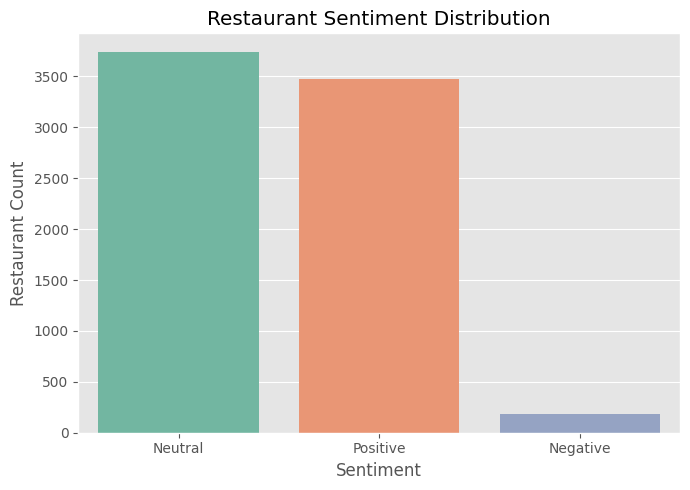

In [10]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=sentiment_summary,
    x="Sentiment",
    y="Restaurant Count",
    palette="Set2"
)

plt.title("Restaurant Sentiment Distribution")

plt.tight_layout()

plt.savefig(
    "../visuals/level3/sentiment_distribution.png",
    dpi=300
)

plt.show()

In [11]:
sentiment_summary.to_csv(
    "../outputs/review_sentiment_analysis.csv",
    index=False
)

## Key Insights

- The dataset does not contain individual customer review text.
- Therefore, keyword extraction and review-length analysis cannot be performed.
- Instead, sentiment analysis was conducted using the available Rating Text categories.
- Most restaurants fall into Positive or Neutral sentiment categories.

## Level 3 – Task 2: Votes Analysis

## Objective

Identify the restaurants with the highest and lowest number of votes and analyze the relationship between votes and restaurant ratings.

In [12]:
highest_votes = (
    df.sort_values(
        by="votes",
        ascending=False
    )
)

highest_votes.head(10)

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes,Sentiment
728,51705,Toit,1,Bangalore,"298, Namma Metro Pillar 62, 100 Feet Road, Ind...",Indiranagar,"Indiranagar, Bangalore",77.640709,12.979166,"Italian, American, Pizza",...,No,No,No,No,4,4.8,Dark Green,Excellent,10934,Positive
735,51040,Truffles,1,Bangalore,"28, 4th 'B' Cross, Koramangala 5th Block, Bang...",Koramangala 5th Block,"Koramangala 5th Block, Bangalore",77.614293,12.933298,"American, Burger, Cafe",...,No,Yes,No,No,2,4.7,Dark Green,Excellent,9667,Positive
3994,308322,Hauz Khas Social,1,New Delhi,"9-A & 12, Hauz Khas Village, New Delhi",Hauz Khas Village,"Hauz Khas Village, New Delhi",77.194471,28.554285,"Continental, American, Asian, North Indian",...,Yes,Yes,No,No,3,4.3,Green,Very Good,7931,Positive
2412,20404,Peter Cat,1,Kolkata,"18A, Park Street, Park Street Area, Kolkata",Park Street Area,"Park Street Area, Kolkata",88.352885,22.552672,"Continental, North Indian",...,No,Yes,No,No,3,4.3,Green,Very Good,7574,Positive
739,56618,AB's - Absolute Barbecues,1,Bangalore,"90/4, 3rd Floor, Outer Ring Road, Munnekollaly...",Marathahalli,"Marathahalli, Bangalore",77.699386,12.949934,"European, Mediterranean, North Indian",...,No,No,No,No,3,4.6,Dark Green,Excellent,6907,Positive
2414,20842,Barbeque Nation,1,Kolkata,"K1, RDB Boulevard, Block EP & GP, Sector 5, Sa...","Sector 5, Salt Lake","Sector 5, Salt Lake, Kolkata",88.433452,22.569358,"North Indian, Chinese",...,No,No,No,No,3,4.9,Dark Green,Excellent,5966,Positive
743,58882,Big Brewsky,1,Bangalore,"Behind MK Retail, Before WIPRO Corporate Offic...",Sarjapur Road,"Sarjapur Road, Bangalore",77.683237,12.913041,"Finger Food, North Indian, Italian, Continenta...",...,Yes,Yes,No,No,3,4.5,Dark Green,Excellent,5705,Positive
2307,94286,AB's - Absolute Barbecues,1,Hyderabad,"Plot 483, 4th Floor, Pemmasani Complex, Bajaj ...",Jubilee Hills,"Jubilee Hills, Hyderabad",78.397865,17.438263,"European, Mediterranean, North Indian",...,No,No,No,No,3,4.9,Dark Green,Excellent,5434,Positive
736,54162,The Black Pearl,1,Bangalore,"105, 1st A Cross Road, Jyothi Nivas College Ro...",Koramangala 5th Block,"Koramangala 5th Block, Bangalore",77.616155,12.934365,"North Indian, European, Mediterranean",...,Yes,No,No,No,3,4.1,Green,Very Good,5385,Positive
2411,20870,BarBQ,1,Kolkata,"43-47-55, Park Street Area, Kolkata",Park Street Area,"Park Street Area, Kolkata",88.352310,22.552996,"Chinese, North Indian",...,No,Yes,No,No,2,4.2,Green,Very Good,5288,Positive


In [13]:
lowest_votes = (
    df.sort_values(
        by="votes"
    )
)

lowest_votes.head(10)

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes,Sentiment
1173,18398616,Aha Bites,1,Gurgaon,"Shop 19, Baba Chitru Complex, Sector 52, Near,...",Ardee City,"Ardee City, Gurgaon",77.089857,28.430857,"Fast Food, North Indian",...,No,No,No,No,1,0.0,White,Not rated,0,NaN
1172,18291229,Achoos Food Corner,1,Gurgaon,"Vohra Market, Near Government School, Ardee Ci...",Ardee City,"Ardee City, Gurgaon",77.078768,28.434728,"South Indian, Chinese, Mughlai",...,No,No,No,No,1,0.0,White,Not rated,0,NaN
8558,18457856,Food Town,1,Noida,"Shop 12, A Block, Sector 31, Noida",Sector 31,"Sector 31, Noida",0.000000,0.000000,"Chinese, North Indian, South Indian",...,No,No,No,No,1,0.0,White,Not rated,0,NaN
6165,18440163,Zaika Restaurant,1,New Delhi,"B-83, Ganesh Nagar Complex, Pandav Nagar, New ...",Pandav Nagar,"Pandav Nagar, New Delhi",77.280266,28.619369,"Mughlai, North Indian",...,No,No,No,No,1,0.0,White,Not rated,0,NaN
6164,18293989,Smily Cakes,1,New Delhi,"B-75, West Vinod Nagar, Pandav Nagar, New Delhi",Pandav Nagar,"Pandav Nagar, New Delhi",77.292414,28.622352,Bakery,...,No,No,No,No,1,0.0,White,Not rated,0,NaN
6161,18449949,Roll Junction,1,New Delhi,"F 205 & 206, Near Akshardham Temple, Pandav Na...",Pandav Nagar,"Pandav Nagar, New Delhi",0.000000,0.000000,North Indian,...,No,No,No,No,1,0.0,White,Not rated,0,NaN
1178,18291231,Gopi Sweets & Caters,1,Gurgaon,"Vohra Market, Near Government School, Ardee Ci...",Ardee City,"Ardee City, Gurgaon",77.078745,28.434686,"Mithai, North Indian",...,No,No,No,No,1,0.0,White,Not rated,0,NaN
1186,18458335,Tanishk Gourmet Indian,1,Gurgaon,"VPO, Wazirabad, Sector 52, Ardee City, Gurgaon",Ardee City,"Ardee City, Gurgaon",0.000000,0.000000,"North Indian, Mughlai, Seafood",...,No,No,No,No,2,0.0,White,Not rated,0,NaN
1185,18471335,Solty Hotel,1,Gurgaon,"Mata Road, Wazirabad, Ardee City, Gurgaon",Ardee City,"Ardee City, Gurgaon",77.083757,28.430634,North Indian,...,No,No,No,No,1,0.0,White,Not rated,0,NaN
1183,18349508,OMG Tiffinz,1,Gurgaon,"1797, Gate 3, Opposite Block D-10, Sector 52, ...",Ardee City,"Ardee City, Gurgaon",77.072861,28.437116,"North Indian, Chinese",...,No,No,No,No,1,0.0,White,Not rated,0,NaN


In [14]:
correlation = df["votes"].corr(
    df["aggregate_rating"]
)

print(f"Correlation: {correlation:.2f}")

Correlation: 0.31


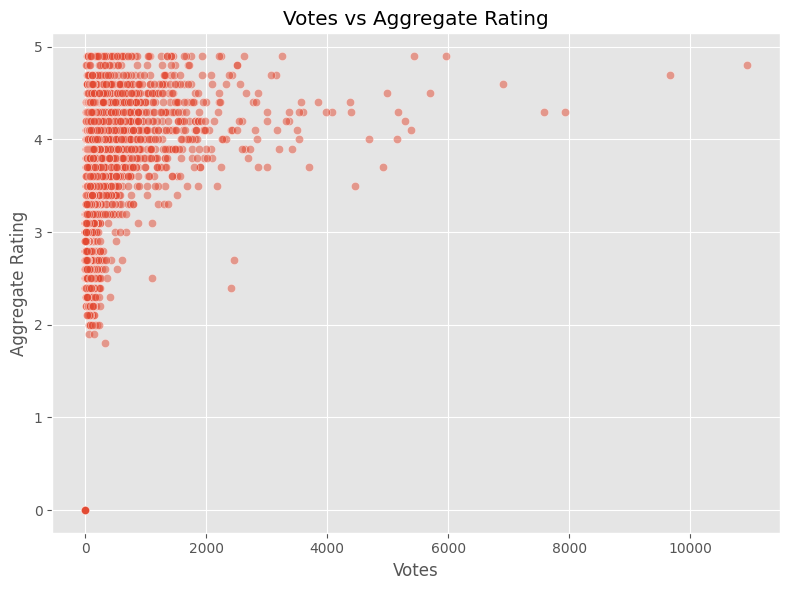

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="votes",
    y="aggregate_rating",
    alpha=0.5
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()

plt.savefig(
    "../visuals/level3/votes_vs_rating.png",
    dpi=300
)

plt.show()

In [16]:
top10_votes = highest_votes[
    ["restaurant_name","city","votes","aggregate_rating"]
].head(10)

top10_votes

,restaurant_name,city,votes,aggregate_rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


In [17]:
top10_votes.to_csv(
    "../outputs/votes_analysis.csv",
    index=False
)

## Key Insights

- Restaurants with the highest votes are generally well-established and popular.
- A positive correlation exists between customer votes and restaurant ratings.
- Highly rated restaurants tend to attract more customer engagement.

## Level 3 – Task 3: Price Range vs Online Delivery & Table Booking

## Objective

Analyze whether higher-priced restaurants are more likely to provide online delivery and table booking services.

In [19]:
online_delivery = pd.crosstab(
    df["price_range"],
    df["has_online_delivery"],
    normalize="index"
) * 100

online_delivery.round(2)

has_online_delivery,No,Yes
price_range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


In [20]:
table_booking = pd.crosstab(
    df["price_range"],
    df["has_table_booking"],
    normalize="index"
) * 100

table_booking.round(2)

has_table_booking,No,Yes
price_range,,
1,99.98,0.02
2,92.32,7.68
3,54.26,45.74
4,53.24,46.76


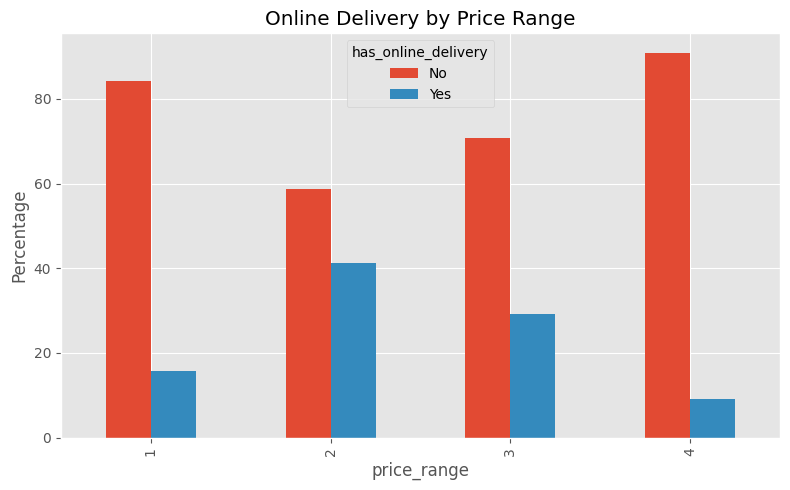

In [21]:
online_delivery.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Delivery by Price Range")
plt.ylabel("Percentage")

plt.tight_layout()

plt.savefig(
    "../visuals/level3/price_vs_delivery.png",
    dpi=300
)

plt.show()

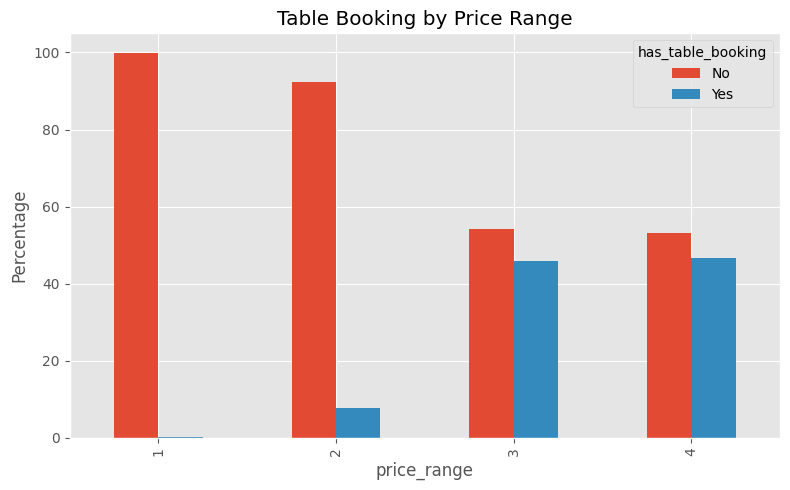

In [22]:
table_booking.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Table Booking by Price Range")
plt.ylabel("Percentage")

plt.tight_layout()

plt.savefig(
    "../visuals/level3/price_vs_booking.png",
    dpi=300
)

plt.show()

In [23]:
online_delivery.to_csv(
    "../outputs/price_vs_delivery.csv"
)

table_booking.to_csv(
    "../outputs/price_vs_booking.csv"
)

## Key Insights

- Higher-priced restaurants generally offer table booking more frequently than lower-priced restaurants.
- Online delivery availability varies across price ranges and is not limited to premium restaurants.
- Premium restaurants prioritize reservation services, while budget restaurants often focus on online delivery.

# Level 3 Summary

### Task 1 – Restaurant Reviews
- Performed sentiment analysis using the available `rating_text` field because review text was not included in the dataset.

### Task 2 – Votes Analysis
- Identified the most and least popular restaurants based on votes.
- Examined the relationship between votes and aggregate ratings using correlation and scatter plots.

### Task 3 – Price Range vs Online Delivery & Table Booking
- Analyzed how service availability changes across different price categories.
- Compared online delivery and table booking percentages for each price range.

Overall, Level 3 provides insights into customer engagement, restaurant popularity, sentiment, and service offerings across different pricing segments.